In [2]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import networkx as nx

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

/Users/theo/PycharmProjects/land_value_prediction_v2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_train = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_train_cleaned.parquet")
df_test  = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_test_cleaned.parquet")
df_oos   = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_cleaned.parquet")

print(df_train.shape, df_test.shape, df_oos.shape)


(507388, 108) (126848, 108) (47768, 108)


In [4]:
df_full_train = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print("Full train shape :", df_full_train.shape)


Full train shape : (634236, 108)


In [5]:
TARGET = 'prix_m2'
LEAKAGE_COLS = ['ecart_prix_median_pct']

cols_to_drop = LEAKAGE_COLS + [TARGET]

X = df_full_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns])
y = df_full_train[TARGET]

print(f"Dimensions initiales de X : {X.shape}")

Dimensions initiales de X : (634236, 106)


A. Détection des groupes corrélés (sans sélection)

In [6]:

X_numeric = X.select_dtypes(include=[np.number])
threshold = 0.90
corr_matrix = X_numeric.corr()

groups_initial = []
visited = set()

for col in corr_matrix.columns:
    if col in visited:
        continue
    group = corr_matrix.index[(corr_matrix[col].abs() > threshold)].tolist()
    if len(group) > 1:
        groups_initial.append(group)
        visited.update(group)

print("\n=== GROUPES INITIAUX (avant fusion) ===")
for g in groups_initial:
    print(g)

# Graphe pour fusionner les groupes
G_corr = nx.Graph()

for group in groups_initial:
    for v in group:
        G_corr.add_node(v)
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            G_corr.add_edge(group[i], group[j])

# Composantes connexes
groups_raw = [list(comp) for comp in nx.connected_components(G_corr)]

print("\n=== GROUPES CORRÉLÉS FUSIONNÉS (propres) ===")
for g in groups_raw:
    print(g)



=== GROUPES INITIAUX (avant fusion) ===
['nombre_lots', 'densite_lots']
['commune_revenu_median_2020', 'commune_idh2_2013_commune']
['commune_etablissements_industrie_2021', 'commune_etablissements_1_salarie_2021', 'commune_etablissements_10_plus_salaries_2021']
['commune_densite_population_active_2020', 'commune_densite_residences_principales_2020', 'commune_densite_pop']
['commune_taux_residences_secondaires', 'commune_ratio_residences_secondaires_population']
['commune_education_score_2013_commune', 'commune_idh2_2013_commune']
['Taux_moyen_credit_immo_lag1t', 'Taux_moyen_credit_immo_lag2t', 'Taux_moyen_credit_immo_lag3t', 'IPC_base_2015_lag1m', 'IPC_base_2015_lag3m', 'IPC_base_2015_lag6m', 'IPC_base_2015_lag12m', 'nb_jours_depuis_janvier_2021']
['Taux_moyen_credit_immo_lag2t', 'Taux_moyen_credit_immo_lag3t', 'Taux_moyen_credit_immo_lag4t', 'IPC_base_2015_lag12m']
['Indice_confiance_menage_lag1m', 'Indice_confiance_menage_lag2m']
['Indice_confiance_menage_lag2m', 'Indice_confiance_

B. Création des groupes structurés

In [7]:
# ============================================================
# 5. Préprocessing + OneHotEncoding (nécessaire pour SHAP)
# ============================================================
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor_fitted = preprocessor.fit(X)

feature_names_enc = preprocessor_fitted.get_feature_names_out()

# mapping encoded -> variable originale
encoded_index_to_variable = {}
for i, name in enumerate(feature_names_enc):
    if name.startswith("num__"):
        encoded_index_to_variable[i] = name.replace("num__", "")
    else:
        encoded_index_to_variable[i] = name.split("_")[0]

original_variables = sorted(list(set(encoded_index_to_variable.values())))

C. Sélection INTELLIGENTE via SHAP

In [8]:
# =====================================================================
# 6. SHAP sur 5 runs stratifiés
# =====================================================================

def stratified_sample(df, target, frac=0.1, bins=20, seed=42):
    df = df.copy()
    df["_bin"] = pd.qcut(df[target], q=bins, duplicates="drop")
    samp = df.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    return samp.drop(columns=["_bin"])

df_full = pd.concat([X, y], axis=1)

N_RUNS = 5
shap_importances_all_runs = {v: [] for v in original_variables}

for run in range(N_RUNS):
    print(f"\n=== SHAP Run {run+1}/{N_RUNS} ===")

    df_sample = stratified_sample(df_full, TARGET, frac=0.10, seed=1000+run)
    Xs = df_sample.drop(columns=[TARGET])
    ys = df_sample[TARGET]

    Xs_enc = preprocessor_fitted.transform(Xs)

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=1000+run,
        n_jobs=-1
    )
    model.fit(Xs_enc, ys)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(Xs_enc)

    shap_abs = np.abs(shap_vals).mean(axis=0)

    var_shap = {v: 0 for v in original_variables}
    for i, val in enumerate(shap_abs):
        var = encoded_index_to_variable[i]
        var_shap[var] += val

    for v in original_variables:
        shap_importances_all_runs[v].append(var_shap[v])

# Agrégation SHAP
shap_stats = pd.DataFrame([
    {"feature": v, "shap_mean": np.mean(vals), "shap_std": np.std(vals)}
    for v, vals in shap_importances_all_runs.items()
]).sort_values("shap_mean", ascending=False)

print("\n=== TOP 20 SHAP FEATURES ===")
print(shap_stats.head(20))


=== SHAP Run 1/5 ===


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(



=== SHAP Run 2/5 ===


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(



=== SHAP Run 3/5 ===


...


=== SHAP Run 4/5 ===


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(



=== SHAP Run 5/5 ===


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_12627/3400534687.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samp = df.groupby("_bin", group_keys=False).apply(



=== TOP 20 SHAP FEATURES ===
                                             feature    shap_mean   shap_std
97                   prix_m2_median_maisons_voisines  1238.523193  93.438072
99                                ratio_terrain_bati   310.661285  23.051092
102                                   surface_x_type   239.996704  12.549092
20              commune_education_score_2013_commune   189.732117  26.999294
45                                 densite_rel_2000m   187.163406  53.693657
95                                       nombre_lots   133.951797  10.876220
62                                  log_surface_bati   129.514603   8.575536
30                    commune_part_commerce_tourisme   120.992233  22.392769
61                                         is_maison   105.153397  12.054613
90                          nb_transport_autre_2000m   102.785683  35.738503
19       commune_densite_residences_principales_2020    98.730240  66.977058
56                                    distance

In [44]:
# =====================================================================
# 7. Sélection intelligente des leaders corrélés via SHAP
# =====================================================================

shap_mean_dict = shap_stats.set_index("feature")["shap_mean"].to_dict()

leaders_final = {}
to_drop_final = []

for group in groups_raw:
    shap_scores = {v: shap_mean_dict.get(v, 0) for v in group}
    best_leader = max(shap_scores, key=shap_scores.get)
    followers = [v for v in group if v != best_leader]

    leaders_final[best_leader] = followers
    to_drop_final.extend(followers)

# Final dedupe
to_drop_final = sorted(list(set(to_drop_final)))

print("\n===== LEADERS (gardés) =====")
for k in leaders_final:
    print("✔️", k)

print("\n===== VARIABLES SUPPRIMÉES =====")
for v in to_drop_final:
    print("❌", v)


===== LEADERS (gardés) =====
✔️ nombre_lots
✔️ commune_education_score_2013_commune
✔️ commune_etablissements_1_salarie_2021
✔️ commune_densite_residences_principales_2020
✔️ commune_ratio_residences_secondaires_population
✔️ nb_jours_depuis_janvier_2021
✔️ Indice_confiance_menage_lag1m
✔️ densite_rel_500m
✔️ densite_rel_2000m
✔️ nb_transport_lourd_2000m
✔️ nb_transport_autre_2000m
✔️ is_maison

===== VARIABLES SUPPRIMÉES =====
❌ IPC_base_2015_lag12m
❌ IPC_base_2015_lag1m
❌ IPC_base_2015_lag3m
❌ IPC_base_2015_lag6m
❌ Indice_confiance_menage_lag2m
❌ Indice_confiance_menage_lag3m
❌ Taux_moyen_credit_immo_lag1t
❌ Taux_moyen_credit_immo_lag2t
❌ Taux_moyen_credit_immo_lag3t
❌ Taux_moyen_credit_immo_lag4t
❌ commune_densite_pop
❌ commune_densite_population_active_2020
❌ commune_etablissements_10_plus_salaries_2021
❌ commune_etablissements_industrie_2021
❌ commune_idh2_2013_commune
❌ commune_revenu_median_2020
❌ commune_taux_residences_secondaires
❌ densite_lots
❌ densite_rel_1000m
❌ is_appar


===== Construction du graphe NetworkX =====


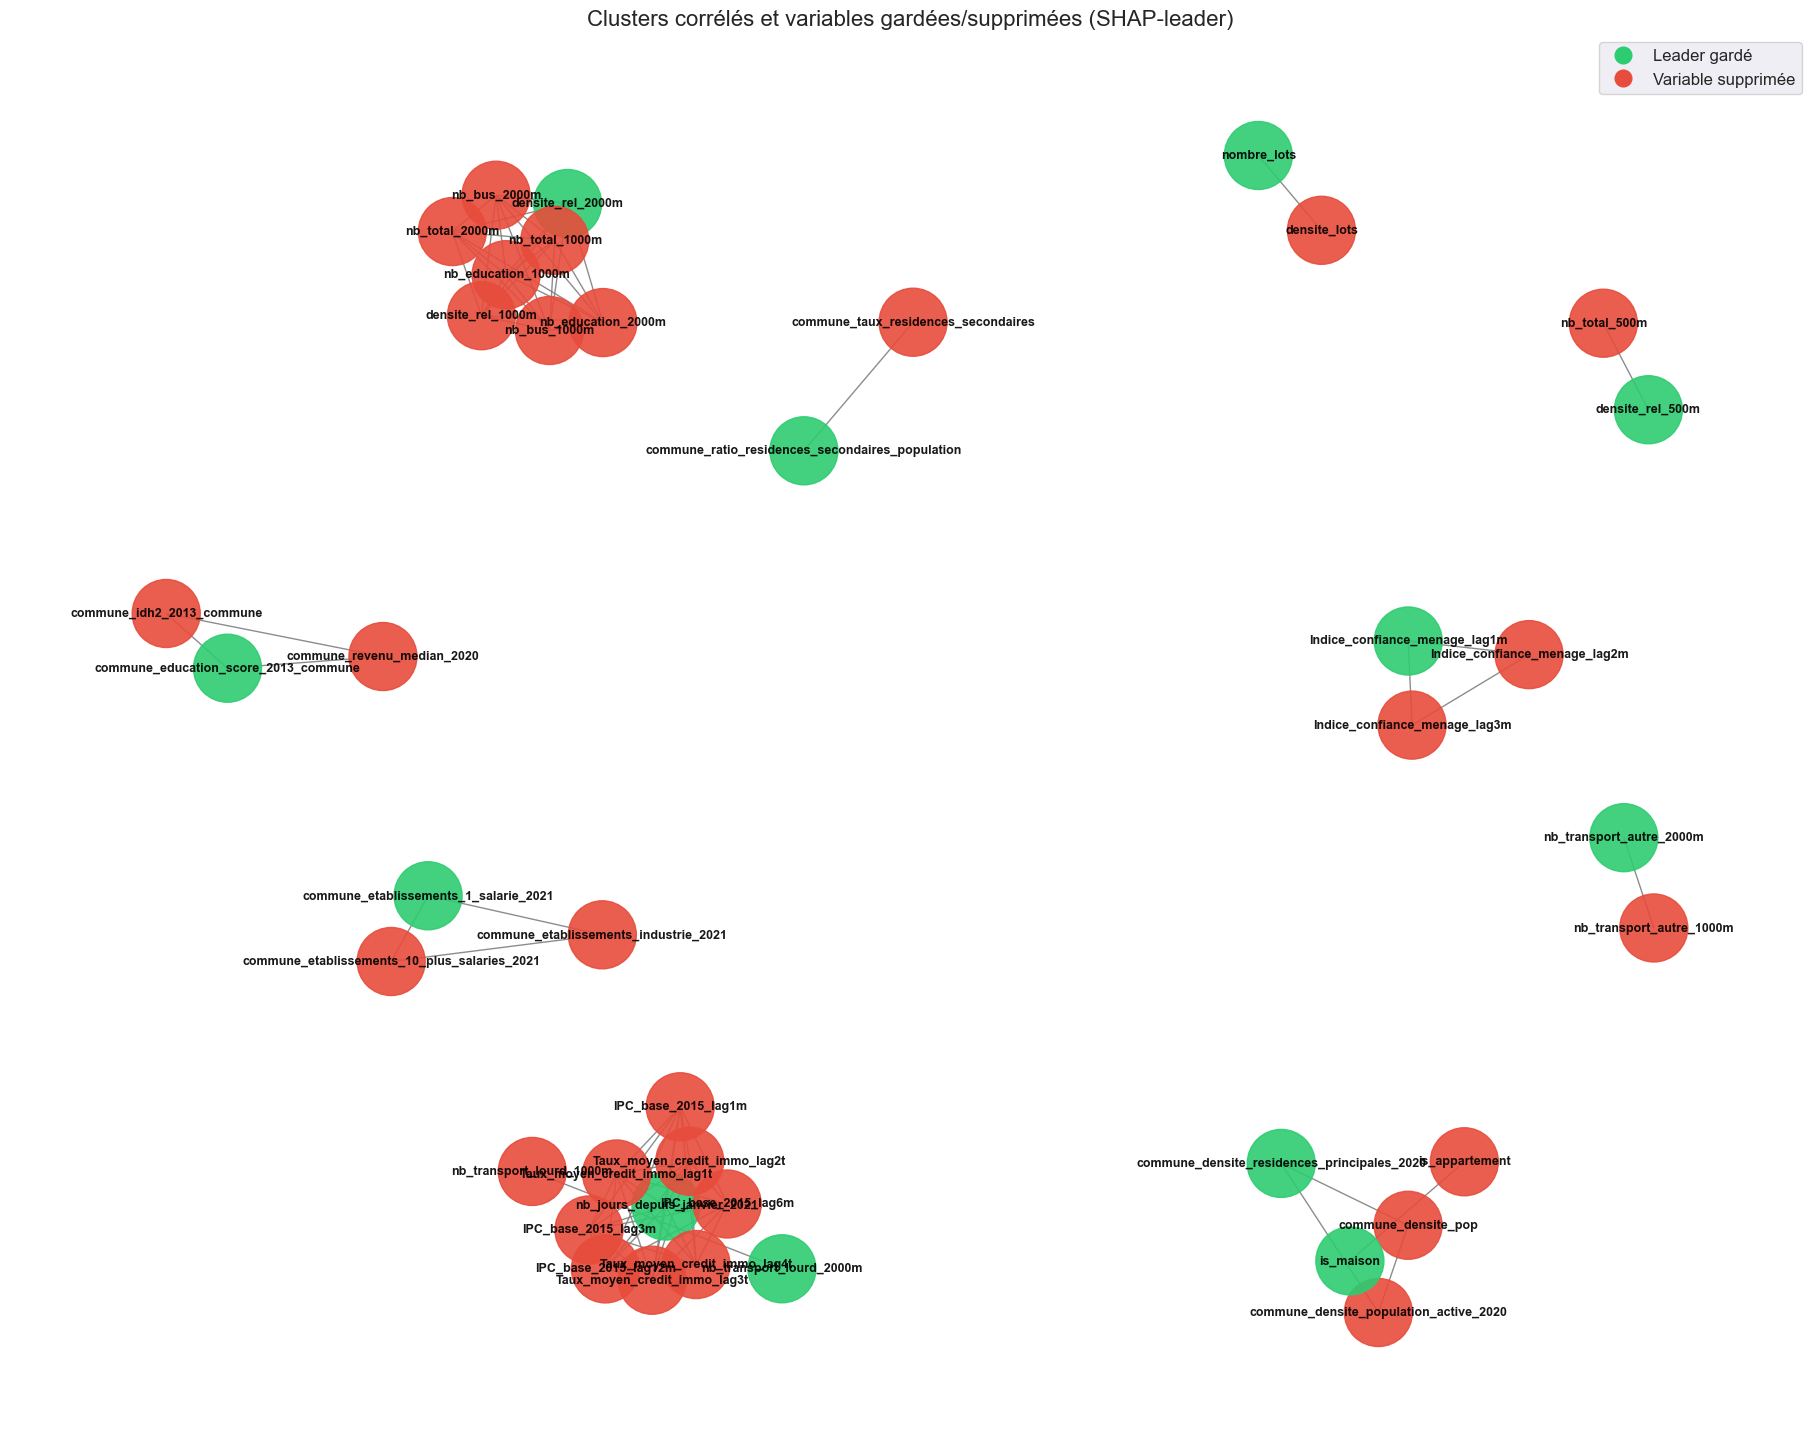

In [50]:
# =====================================================================
# GRAPHIQUE NETWORKX — Clusters corrélés et leaders SHAP
# =====================================================================

import matplotlib.pyplot as plt

print("\n===== Construction du graphe NetworkX =====")

G = nx.Graph()

# 1. Ajouter les noeuds
for leader, followers in leaders_final.items():
    G.add_node(leader, color='green')
    for f in followers:
        G.add_node(f, color='red')
        G.add_edge(leader, f)

# 2. Ajouter liens entre variables d'un même cluster fusionné
for group in groups_raw:
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            if group[i] in G.nodes and group[j] in G.nodes:
                G.add_edge(group[i], group[j])

# 3. Couleurs
node_colors = ["#2ecc71" if G.nodes[n]["color"] == 'green'
               else "#e74c3c" for n in G.nodes()]

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, k=0.45, iterations=60, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2400,
    font_size=9,
    font_weight="bold",
    edge_color="gray",
    alpha=0.9
)

plt.plot([], [], 'o', color="#2ecc71", ms=12, label="Leader gardé")
plt.plot([], [], 'o', color="#e74c3c", ms=12, label="Variable supprimée")
plt.legend(fontsize=12)

plt.title("Clusters corrélés et variables gardées/supprimées (SHAP-leader)", fontsize=16)
plt.show()


In [65]:
# =====================================================================
# 8. Application du nettoyage sur les datasets finaux
# =====================================================================

# Variable de fuite à supprimer systématiquement
LEAKAGE_COLS = ["ecart_prix_median_pct"]

# Liste complète des colonnes à retirer
cols_to_remove = list(set(to_drop_final + LEAKAGE_COLS + [TARGET]))

print("Colonnes supprimées :", cols_to_remove)

# 1. Dataset d'ENTRAÎNEMENT (Train + Test réunis)
X_train_final = df_full_train.drop(columns=cols_to_remove, errors='ignore')
y_train_final = df_full_train[TARGET]

# 2. Dataset OUT OF SAMPLE (Validation future)
X_oos_final = df_oos.drop(columns=cols_to_remove, errors='ignore')
y_oos_final = df_oos[TARGET]

# Vérification des dimensions
print(f"Dimensions X entraînement (Full) : {X_train_final.shape}")
print(f"Dimensions X validation (OOS)    : {X_oos_final.shape}")

# Vérification que les colonnes sont identiques
assert list(X_train_final.columns) == list(X_oos_final.columns), \
    "❌ ERREUR : Les colonnes du Train et du OOS ne correspondent pas !"

print("✅ Colonnes alignées. Modèles prêts à être entraînés !")


Colonnes supprimées : ['nb_education_1000m', 'commune_etablissements_10_plus_salaries_2021', 'Indice_confiance_menage_lag3m', 'commune_densite_pop', 'commune_idh2_2013_commune', 'nb_transport_lourd_1000m', 'nb_bus_1000m', 'Taux_moyen_credit_immo_lag4t', 'nb_total_500m', 'Taux_moyen_credit_immo_lag2t', 'IPC_base_2015_lag1m', 'nb_bus_2000m', 'commune_taux_residences_secondaires', 'Taux_moyen_credit_immo_lag1t', 'commune_revenu_median_2020', 'densite_rel_1000m', 'nb_transport_autre_1000m', 'nb_total_1000m', 'nb_total_2000m', 'IPC_base_2015_lag12m', 'commune_etablissements_industrie_2021', 'IPC_base_2015_lag6m', 'prix_m2', 'nb_education_2000m', 'Taux_moyen_credit_immo_lag3t', 'Indice_confiance_menage_lag2m', 'densite_lots', 'commune_densite_population_active_2020', 'ecart_prix_median_pct', 'IPC_base_2015_lag3m', 'is_appartement']
Dimensions X entraînement (Full) : (634236, 77)
Dimensions X validation (OOS)    : (47768, 77)
✅ Colonnes alignées. Modèles prêts à être entraînés !


   PIPELINE XGBOOST FINAL : OPTIMISATION & TRAINING  

[1/5] On réutilise X_train_final / X_oos_final créés après le SHAP...
 -> Dimensions Train final : (634236, 77)
 -> Dimensions OOS final   : (47768, 77)

[2/5] Configuration du Pipeline de préprocessing...

[3/5] Création de l'échantillon stratifié pour Optuna...


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1277/1002606145.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1277/1002606145.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(


 -> Optuna travaillera sur : (49998, 77) lignes (7.9%)

[4/5] Lancement d'Optuna (Recherche des meilleurs paramètres)...


Best trial: 20. Best value: 1569.37: 100%|██████████| 30/30 [56:33<00:00, 113.13s/it]



✅ Optuna terminé !
 -> Meilleur RMSE (Sample) : 1569.37
 -> Meilleur MAE  (Sample) : 1022.65
 -> Meilleurs paramètres : {'n_estimators': 380, 'max_depth': 8, 'learning_rate': 0.021620708426390325, 'subsample': 0.7291122472749192, 'colsample_bytree': 0.6981086550311786, 'min_child_weight': 4, 'gamma': 2.773246263132245, 'reg_alpha': 6.7333138112382676, 'reg_lambda': 0.01176510024607813}

[5/5] Entraînement du Modèle Final XGBoost sur TOUT le dataset...

  RÉSULTATS FINAUX XGBOOST (Dataset OOS Jamais Vu)  
RMSE : 1449.61 €/m²
MAE  : 965.07 €/m²
R²   : 0.7765


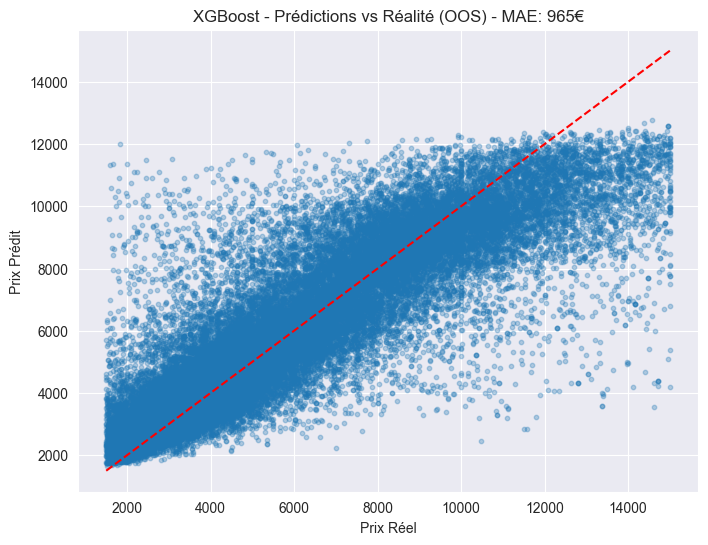

In [66]:
import optuna
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=======================================================")
print("   PIPELINE XGBOOST FINAL : OPTIMISATION & TRAINING  ")
print("=======================================================")

# =====================================================================
# 1. PRÉPARATION DES DONNÉES FINALES (déjà nettoyées par SHAP)
# =====================================================================
print("\n[1/5] On réutilise X_train_final / X_oos_final créés après le SHAP...")

print(f" -> Dimensions Train final : {X_train_final.shape}")
print(f" -> Dimensions OOS final   : {X_oos_final.shape}")

# =====================================================================
# 2. CONFIGURATION DU PRÉPROCESSEUR
# =====================================================================
print("\n[2/5] Configuration du Pipeline de préprocessing...")

numeric_features = X_train_final.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_final.columns if c not in numeric_features]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ce préprocesseur servira aussi pour le stacking plus tard
preprocessor_final = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =====================================================================
# 3. SAMPLING STRATIFIÉ POUR OPTUNA (Gain de temps)
# =====================================================================
print("\n[3/5] Création de l'échantillon stratifié pour Optuna...")

target_sample_size = 50_000
frac_sample = target_sample_size / len(X_train_final)
if frac_sample > 1.0:
    frac_sample = 1.0

def stratified_sample(X, y, frac, bins=20, seed=42):
    df_tmp = pd.concat([X, y], axis=1)
    df_tmp["_bin"] = pd.qcut(df_tmp[y.name], q=bins, duplicates="drop")

    df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )

    X_out = df_samp.drop(columns=[y.name, "_bin"])
    y_out = df_samp[y.name]
    return X_out, y_out

X_sample, y_sample = stratified_sample(X_train_final, y_train_final, frac=frac_sample)
print(f" -> Optuna travaillera sur : {X_sample.shape} lignes ({frac_sample:.1%})")

# =====================================================================
# 4. OPTIMISATION BAYÉSIENNE (OPTUNA)
# =====================================================================
print("\n[4/5] Lancement d'Optuna (Recherche des meilleurs paramètres)...")

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.95),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
    }

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
        **params
    )

    pipe = Pipeline([("preprocess", preprocessor_final), ("model", model)])

    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_validate(
        pipe, X_sample, y_sample,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'],
        cv=cv, n_jobs=-1
    )

    rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    mae = -scores['test_neg_mean_absolute_error'].mean()

    trial.set_user_attr("mae", mae)
    return rmse

N_TRIALS = 30
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✅ Optuna terminé !")
print(f" -> Meilleur RMSE (Sample) : {study_xgb.best_value:.2f}")
print(f" -> Meilleur MAE  (Sample) : {study_xgb.best_trial.user_attrs['mae']:.2f}")
print(" -> Meilleurs paramètres :", study_xgb.best_params)

# On met ça dans une variable avec un nom explicite pour le stacking
best_params_xgb = study_xgb.best_params

# =====================================================================
# 5. ENTRAÎNEMENT FINAL & ÉVALUATION OOS
# =====================================================================
print("\n[5/5] Entraînement du Modèle Final XGBoost sur TOUT le dataset...")

model_final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42,
    **best_params_xgb
)

pipe_final_xgb = Pipeline([
    ("preprocess", preprocessor_final),
    ("model", model_final_xgb)
])

pipe_final_xgb.fit(X_train_final, y_train_final)

print("\n=======================================================")
print("  RÉSULTATS FINAUX XGBOOST (Dataset OOS Jamais Vu)  ")
print("=======================================================")

y_pred_oos_xgb = pipe_final_xgb.predict(X_oos_final)

rmse_oos_xgb = np.sqrt(mean_squared_error(y_oos_final, y_pred_oos_xgb))
mae_oos_xgb = mean_absolute_error(y_oos_final, y_pred_oos_xgb)
r2_oos_xgb = r2_score(y_oos_final, y_pred_oos_xgb)

print(f"RMSE : {rmse_oos_xgb:.2f} €/m²")
print(f"MAE  : {mae_oos_xgb:.2f} €/m²")
print(f"R²   : {r2_oos_xgb:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_oos_final, y_pred_oos_xgb, alpha=0.3, s=10)
plt.plot([y_oos_final.min(), y_oos_final.max()],
         [y_oos_final.min(), y_oos_final.max()], 'r--')
plt.xlabel("Prix Réel")
plt.ylabel("Prix Prédit")
plt.title(f"XGBoost - Prédictions vs Réalité (OOS) - MAE: {mae_oos_xgb:.0f}€")
plt.show()



  📊 IMPORTANCE DES VARIABLES (XGBOOST)  

Top 10 des variables les plus influentes (XGBoost) :
                                            feature  importance
3                   prix_m2_median_maisons_voisines    0.329618
61                         nb_transport_autre_2000m    0.297548
10      commune_densite_residences_principales_2020    0.042282
63                                densite_rel_2000m    0.030977
72                                        is_maison    0.022950
9   commune_ratio_residences_secondaires_population    0.019544
15                   commune_part_commerce_tourisme    0.019335
20             commune_education_score_2013_commune    0.016859
6             commune_etablissements_1_salarie_2021    0.014534
65                               ratio_terrain_bati    0.012133


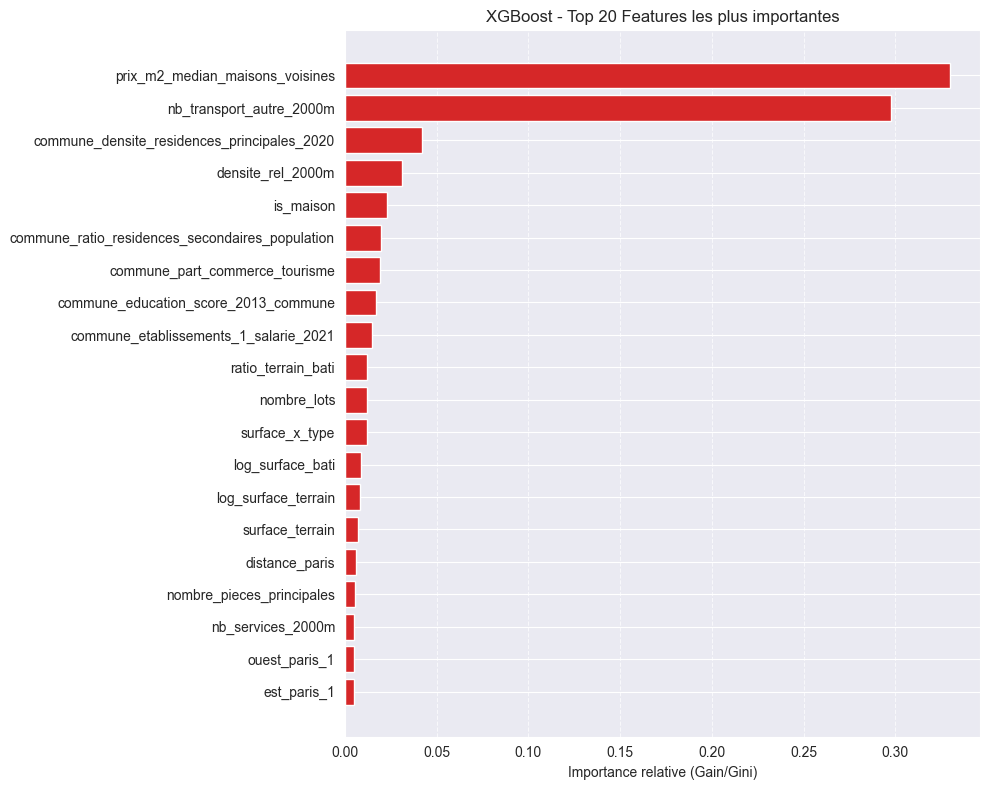

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 7. ANALYSE DES FEATURE IMPORTANCES (XGBOOST)
# =====================================================================
print("\n=======================================================")
print("  📊 IMPORTANCE DES VARIABLES (XGBOOST)  ")
print("=======================================================")

# 1. Récupération des étapes du pipeline XGBoost
# Assure-toi que 'pipe_final_xgb' est bien ton pipeline entraîné
preprocessor = pipe_final_xgb.named_steps["preprocess"]
xgb_model = pipe_final_xgb.named_steps["model"]

# 2. Récupération des noms des features
feature_names = preprocessor.get_feature_names_out()

# 3. Récupération des importances
importances = xgb_model.feature_importances_

# 4. Création du DataFrame
df_importance_xgb = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# --- NETTOYAGE DES NOMS (On enlève 'num__' et 'cat__') ---
# On remplace "num__" et "cat__" par rien du tout pour avoir des noms propres
df_importance_xgb["feature"] = df_importance_xgb["feature"].str.replace("num__", "").str.replace("cat__", "")

# On trie
df_importance_xgb = df_importance_xgb.sort_values(by="importance", ascending=False)

# Affichage console
print("\nTop 10 des variables les plus influentes (XGBoost) :")
print(df_importance_xgb.head(10))

# 5. Visualisation Graphique
top_n = 20
df_plot = df_importance_xgb.head(top_n).sort_values(by="importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_plot["feature"], df_plot["importance"], color="#d62728") # Rouge pour XGBoost
plt.xlabel("Importance relative (Gain/Gini)")
plt.title(f"XGBoost - Top {top_n} Features les plus importantes")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

  🌲 PIPELINE RANDOM FOREST : OPTIMISATION & TRAINING  
Dataset d'entraînement : (634236, 77)
Dataset OOS (Validation) : (47768, 77)

[Sampling] Création de l'échantillon pour Optuna RF (~30000 lignes)...


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1277/1339034952.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_1277/1339034952.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(


 -> RF Optuna sample : (30000, 77)

[Optuna] Lancement de l'optimisation des hyperparamètres RF...


Best trial: 15. Best value: 1592.89: 100%|██████████| 20/20 [13:48<00:00, 41.43s/it]



✅ Optuna RF terminé !
 -> Meilleur RMSE (Sample) : 1592.89
 -> Meilleur MAE  (Sample) : 1040.51
 -> Meilleurs paramètres RF : {'n_estimators': 153, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.4021423451454492}

[Final] Entraînement du Random Forest Final sur TOUT le dataset...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 153 out of 153 | elapsed:  8.1min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.



  🏆 RÉSULTATS FINAUX RANDOM FOREST (OOS)  


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


RMSE : 1029.45 €/m²
MAE  : 694.48 €/m²
R²   : 0.8873


[Parallel(n_jobs=8)]: Done 153 out of 153 | elapsed:    0.3s finished


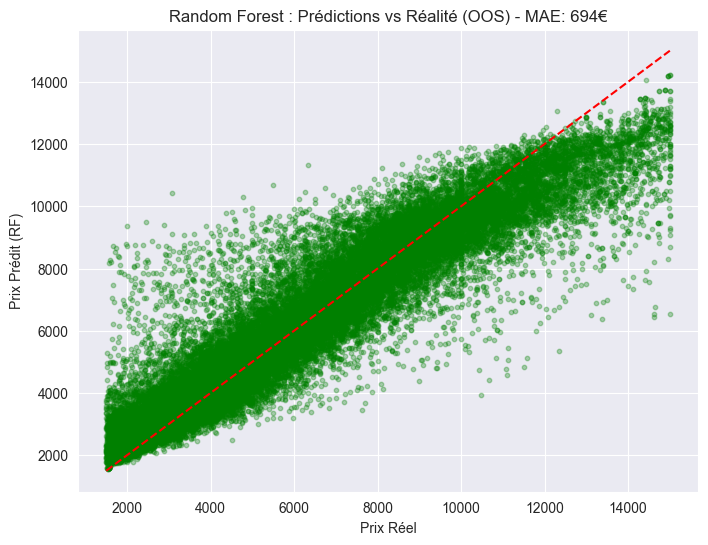

In [67]:
import optuna
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=======================================================")
print("  🌲 PIPELINE RANDOM FOREST : OPTIMISATION & TRAINING  ")
print("=======================================================")

print(f"Dataset d'entraînement : {X_train_final.shape}")
print(f"Dataset OOS (Validation) : {X_oos_final.shape}")

# =====================================================================
# 2. PRÉPROCESSEUR RF
# =====================================================================

numeric_features = X_train_final.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_final.columns if c not in numeric_features]

numeric_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_rf = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_features),
    ("cat", categorical_transformer_rf, categorical_features)
])

# =====================================================================
# 3. SAMPLING STRATIFIÉ (Pour Optuna RF)
# =====================================================================
target_sample_size_rf = 30_000
frac_sample_rf = target_sample_size_rf / len(X_train_final)
if frac_sample_rf > 1.0:
    frac_sample_rf = 1.0

def stratified_sample_rf(X, y, frac, bins=20, seed=42):
    df_tmp = pd.concat([X, y], axis=1)
    df_tmp["_bin"] = pd.qcut(df_tmp[y.name], q=bins, duplicates="drop")
    df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    return df_samp.drop(columns=[y.name, "_bin"]), df_samp[y.name]

print(f"\n[Sampling] Création de l'échantillon pour Optuna RF (~{target_sample_size_rf} lignes)...")
X_sample_rf, y_sample_rf = stratified_sample_rf(X_train_final, y_train_final, frac=frac_sample_rf)
print(f" -> RF Optuna sample : {X_sample_rf.shape}")

# =====================================================================
# 4. OPTUNA POUR RANDOM FOREST
# =====================================================================
print("\n[Optuna] Lancement de l'optimisation des hyperparamètres RF...")

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.3, 0.9)
    }

    model = RandomForestRegressor(
        n_jobs=-1,
        random_state=42,
        **params
    )

    pipe = Pipeline([("preprocess", preprocessor_rf), ("model", model)])

    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_validate(
        pipe, X_sample_rf, y_sample_rf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'],
        cv=cv, n_jobs=-1
    )

    rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    mae = -scores['test_neg_mean_absolute_error'].mean()

    trial.set_user_attr("mae", mae)
    return rmse

N_TRIALS_RF = 20
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=True)

print(f"\n✅ Optuna RF terminé !")
print(f" -> Meilleur RMSE (Sample) : {study_rf.best_value:.2f}")
print(f" -> Meilleur MAE  (Sample) : {study_rf.best_trial.user_attrs['mae']:.2f}")
print(" -> Meilleurs paramètres RF :", study_rf.best_params)

best_params_rf = study_rf.best_params

# =====================================================================
# 5. ENTRAÎNEMENT FINAL (Full Dataset)
# =====================================================================
print("\n[Final] Entraînement du Random Forest Final sur TOUT le dataset...")

model_final_rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    verbose=1,
    **best_params_rf
)

pipe_final_rf = Pipeline([
    ("preprocess", preprocessor_rf),
    ("model", model_final_rf)
])

pipe_final_rf.fit(X_train_final, y_train_final)

# =====================================================================
# 6. ÉVALUATION OOS
# =====================================================================
print("\n=======================================================")
print("  🏆 RÉSULTATS FINAUX RANDOM FOREST (OOS)  ")
print("=======================================================")

y_pred_oos_rf = pipe_final_rf.predict(X_oos_final)

rmse_oos_rf = np.sqrt(mean_squared_error(y_oos_final, y_pred_oos_rf))
mae_oos_rf = mean_absolute_error(y_oos_final, y_pred_oos_rf)
r2_oos_rf = r2_score(y_oos_final, y_pred_oos_rf)

print(f"RMSE : {rmse_oos_rf:.2f} €/m²")
print(f"MAE  : {mae_oos_rf:.2f} €/m²")
print(f"R²   : {r2_oos_rf:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_oos_final, y_pred_oos_rf, alpha=0.3, s=10, c='green')
plt.plot([y_oos_final.min(), y_oos_final.max()],
         [y_oos_final.min(), y_oos_final.max()], 'r--')
plt.xlabel("Prix Réel")
plt.ylabel("Prix Prédit (RF)")
plt.title(f"Random Forest : Prédictions vs Réalité (OOS) - MAE: {mae_oos_rf:.0f}€")
plt.show()



  📊 IMPORTANCE DES VARIABLES (RANDOM FOREST)  

Top 10 des variables les plus influentes :
                                             feature  importance
3               num__prix_m2_median_maisons_voisines    0.332060
61                     num__nb_transport_autre_2000m    0.156104
63                            num__densite_rel_2000m    0.065709
6         num__commune_etablissements_1_salarie_2021    0.065268
10  num__commune_densite_residences_principales_2020    0.054438
15               num__commune_part_commerce_tourisme    0.033021
71                               num__surface_x_type    0.023871
66                             num__log_surface_bati    0.021479
65                           num__ratio_terrain_bati    0.020860
69                               num__distance_paris    0.018849


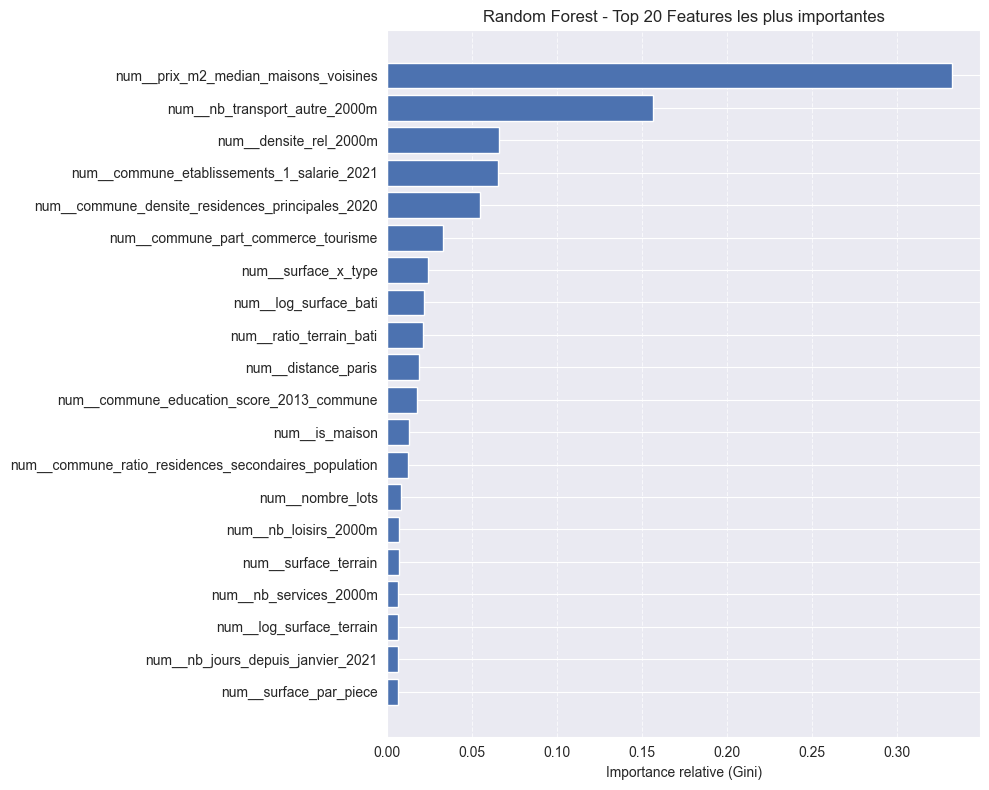

In [82]:
# =====================================================================
# 7. ANALYSE DES FEATURE IMPORTANCES
# =====================================================================
print("\n=======================================================")
print("  📊 IMPORTANCE DES VARIABLES (RANDOM FOREST)  ")
print("=======================================================")

# 1. Récupération des étapes du pipeline
preprocessor = pipe_final_rf.named_steps["preprocess"]
rf_model = pipe_final_rf.named_steps["model"]

# 2. Récupération des noms des features après transformation
# get_feature_names_out() gère automatiquement les noms créés par le OneHotEncoder
feature_names = preprocessor.get_feature_names_out()

# 3. Récupération des importances calculées par le Random Forest
importances = rf_model.feature_importances_

# 4. Création d'un DataFrame pour trier et visualiser
df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Affichage des 10 plus importantes dans la console
print("\nTop 10 des variables les plus influentes :")
print(df_importance.head(10))

# 5. Visualisation Graphique (Top 20)
top_n = 20
df_plot = df_importance.head(top_n).sort_values(by="importance", ascending=True) # Tri inversé pour le graph

plt.figure(figsize=(10, 8))
plt.barh(df_plot["feature"], df_plot["importance"], color="#4c72b0")
plt.xlabel("Importance relative (Gini)")
plt.title(f"Random Forest - Top {top_n} Features les plus importantes")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

print("=======================================================")
print("  🏗️ CODE COMPLET : STACKING ROBUSTE & COMPARATIF  ")
print("=======================================================")

# =====================================================================
# 1. CONFIGURATION DES MODÈLES DE BASE (NIVEAU 1)
# =====================================================================
print(" -> Initialisation des modèles avec barres de progression...")

# --- A. Random Forest ---
rf_model_stack = RandomForestRegressor(
    n_estimators=300,
    n_jobs=-1,
    random_state=42,
    verbose=1  # Affiche l'avancement
)

# --- B. HistGradientBoosting (Le remplaçant natif de XGBoost) ---
hgb_model_stack = HistGradientBoostingRegressor(
    learning_rate=best_params_xgb.get('learning_rate', 0.1),
    max_depth=best_params_xgb.get('max_depth', 8),
    max_iter=best_params_xgb.get('n_estimators', 300),
    l2_regularization=best_params_xgb.get('reg_lambda', 1.0),
    random_state=42,
    verbose=1  # Affiche l'avancement
)

# =====================================================================
# 2. CONSTRUCTION DU STACKING (NIVEAU 2)
# =====================================================================

# Le "Juge" (Final Estimator) sera une Ridge Regression (Linéaire régularisé)
stacking_model = StackingRegressor(
    estimators=[
        ('hgb', hgb_model_stack), # L'expert Boosting
        ('rf', rf_model_stack)    # L'expert Forêt
    ],
    final_estimator=RidgeCV(),
    cv=3,             # Cross-validation interne pour entraîner le juge
    n_jobs=-1,
    passthrough=False,
    verbose=1         # Le Stacking nous dira où il en est
)

# Pipeline Global
stacking_pipe = Pipeline([
    ("preprocess", preprocessor_final),
    ("stack", stacking_model)
])

# =====================================================================
# 3. ENTRAÎNEMENT (C'est parti !)
# =====================================================================
print("\n[Stacking] 🚀 Démarrage de l'entraînement...")
print("-" * 60)

stacking_pipe.fit(X_train_final, y_train_final)

print("-" * 60)
print("✅ VICTOIRE ! Le Stacking est entraîné.")

# =====================================================================
# 4. LE GRAND TOURNOI : XGB vs RF vs STACKING
# =====================================================================
print("\n=======================================================")
print("  ⚔️ LE VERDICT FINAL (Sur données OOS jamais vues)  ")
print("=======================================================")

# On récupère les prédictions des 3 pipelines
# (On suppose que pipe_final_xgb et pipe_final_rf sont toujours en mémoire)
pred_xgb   = pipe_final_xgb.predict(X_oos_final)
pred_rf    = pipe_final_rf.predict(X_oos_final)
pred_stack = stacking_pipe.predict(X_oos_final)

# Calcul des scores MAE
mae_xgb   = mean_absolute_error(y_oos_final, pred_xgb)
mae_rf    = mean_absolute_error(y_oos_final, pred_rf)
mae_stack = mean_absolute_error(y_oos_final, pred_stack)

# Affichage Texte
print(f"📊 RÉSULTATS (MAE - Plus petit = Mieux) :")
print(f" -> 1. XGBoost Seul     : {mae_xgb:.2f} €/m²")
print(f" -> 2. Random Forest    : {mae_rf:.2f} €/m²")
print(f" -> 3. Stacking (Mixte) : {mae_stack:.2f} €/m²")

# Détermination du gagnant solo (RF ou XGB ?)
if mae_rf < mae_xgb:
    best_single = "Random Forest"
    best_score = mae_rf
else:
    best_single = "XGBoost"
    best_score = mae_xgb

# Comparaison Stacking vs Meilleur Solo
gain = best_score - mae_stack

print("\n--- CONCLUSION ---")
if gain > 0:
    print(f"🏆 LE STACKING EST MEILLEUR ! Gain de {gain:.2f}€ par rapport au {best_single}.")
else:
    print(f"⚠️ LE STACKING N'AMÉLIORE PAS LE RÉSULTAT.")
    print(f"   Le {best_single} reste le meilleur modèle (écart de {abs(gain):.2f}€).")
    print("   -> Conseil : Gardez le modèle simple pour la mise en prod.")

# =====================================================================
# 5. GRAPHIQUE FINAL
# =====================================================================
models = ['XGBoost', 'Random Forest', 'Stacking']
scores = [mae_xgb, mae_rf, mae_stack]
# Couleur : Gris pour les perdants, Vert pour le Stacking s'il gagne, Rouge s'il perd
colors = ['gray', 'gray', 'green' if gain > 0 else 'firebrick']

plt.figure(figsize=(9, 6))
bars = plt.bar(models, scores, color=colors, edgecolor='black', alpha=0.8)

# Ajout des valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}€',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Erreur Moyenne Absolue (€/m²)')
plt.title('Comparaison Finale des Performances')
plt.ylim(bottom=min(scores)*0.9)
plt.grid(axis='y', alpha=0.3)
plt.show()

  🏗️ CODE COMPLET : STACKING ROBUSTE & COMPARATIF  
 -> Initialisation des modèles avec barres de progression...

[Stacking] 🚀 Démarrage de l'entraînement...
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


Binning 0.370 GB of training data: 9.679 s
Binning 0.041 GB of validation data: 0.959 s
Fitting gradient boosted rounds:
Fit 380 trees in 228.174 s, (11780 total leaves)
Time spent computing histograms: 188.055s
Time spent finding best splits:  4.302s
Time spent applying splits:      15.856s
Time spent predicting:           1.615s


[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  7.3min
